### Dynamic Programming 1: 

https://www.geeksforgeeks.org/dsa/dynamic-programming/

Claude explanation: 

**Dynamic programming (DP)** is a technique for solving problems by breaking them into smaller overlapping subproblems, solving each subproblem once, and storing the result so it can be reused instead of recomputed.

It works when a problem has two properties. The first is **optimal substructure**: the best solution to the whole problem can be built from the best solutions to its subproblems. The second is **overlapping subproblems**: the same subproblems come up again and again, so caching their answers saves a lot of work. (Divide-and-conquer methods like merge sort also split problems up, but their subproblems don't repeat, so caching wouldn't help.)

There are two common ways to implement it:

- **Top-down (memoization):** write the natural recursive solution, and store each result in a table or dictionary the first time you compute it.
- **Bottom-up (tabulation):** fill a table iteratively, starting from the smallest subproblems and working up to the full problem.

**Example: Fibonacci.** Computing F(n) = F(n−1) + F(n−2) naively takes exponential time, because F(n−2) gets recomputed inside F(n−1), and so on. Storing each value once brings it down to O(n):

```python
def fib(n):
    dp = [0, 1]
    for i in range(2, n + 1):
        dp.append(dp[i-1] + dp[i-2])
    return dp[n]
```

Classic DP problems include knapsack, longest common subsequence, edit distance, coin change, shortest paths (Bellman–Ford, Floyd–Warshall), and counting paths in a grid.

The hard part is usually defining the **state**, meaning what a subproblem represents, such as "dp[i] = the best answer using the first i items." You then write the **recurrence**, which says how a state is computed from smaller states, and handle the **base cases**. Once those three are clear, the code tends to follow directly.

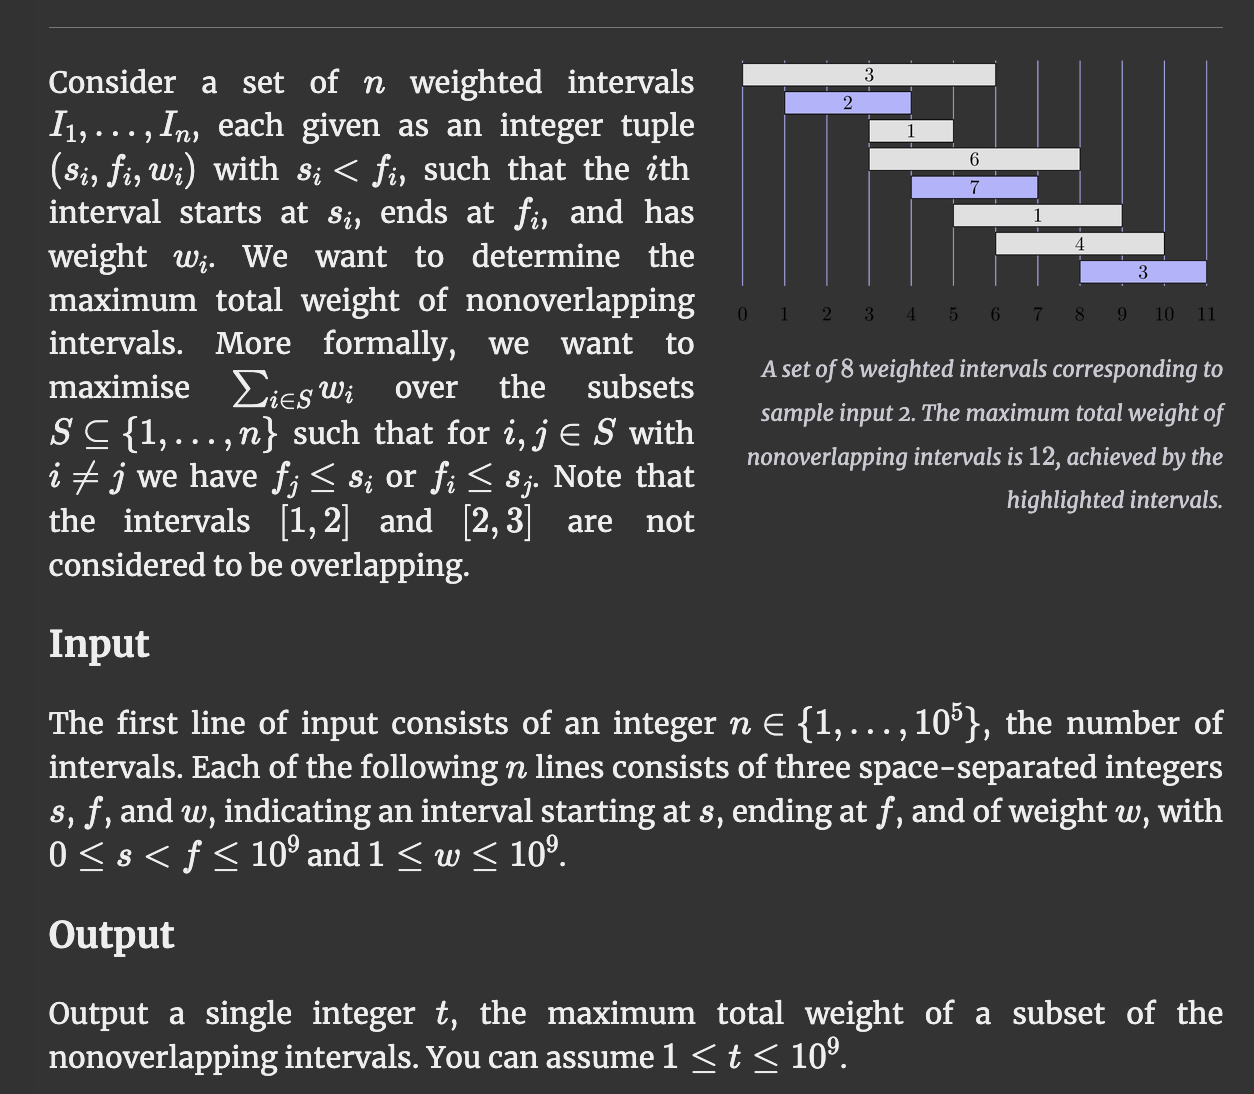

In [2]:
sample_input1 = """
3
1 4 1
2 8 3
5 9 1
"""

#Output: 3

sample_input2 = """
8
0 6 3
1 4 2
3 5 1
3 8 6
4 7 7
5 9 1
6 10 4
8 11 3
"""

#Output: 12

### Imports

In [3]:
import sys, io


### Input

In [24]:
data = sample_input2

lines = data.strip().splitlines()         # local testing
lines

['8', '0 6 3', '1 4 2', '3 5 1', '3 8 6', '4 7 7', '5 9 1', '6 10 4', '8 11 3']

In [ ]:
num_intervals = int(lines[0])
intervals = []


for i in lines[1:]:
    interval = tuple(map(int, i.split()))

    intervals.append(interval)

intervals.sort(key=lambda x: x[1])   



#print(intervals)


In [40]:
finish = []

for interval in intervals:
    finish.append(interval[1])

table = [0] * (num_intervals + 1)

for j in range(1, num_intervals + 1):
    start, finish, weight = intervals[j-1]

    count = 0 
    
    for k in range (j - 1):
        if intervals[k][1] <= start:
            count += 1 

    table[j] = max(table[j-1], weight + table[count])

#print(finish)
#print(table)
print(table[num_intervals])

12


In [2]:
#all in one
import sys
#data = sample_input2

#lines = data.strip().splitlines()         # local testing
#lines
lines = sys.stdin.read().strip().splitlines()

num_intervals = int(lines[0])
intervals = []


for i in lines[1:]:
    interval = tuple(map(int, i.split()))
    intervals.append(interval)

intervals.sort(key=lambda x: x[1])

ends = []

for interval in intervals:
    ends.append(interval[1])

table = [0] * (num_intervals + 1)

for j in range(1, num_intervals + 1):
    start, finish, weight = intervals[j-1]

    low = 0
    high = j - 1

    while low < high:
        mid = (low + high) // 2
        if ends[mid] <= start:
            low = mid + 1
        else:
            high = mid

    count = low

    table[j] = max(table[j-1], weight + table[count])

#print(finish)
#print(table)
print(table[num_intervals])


KeyboardInterrupt: 